<a href="https://colab.research.google.com/github/AkhilaSunesh/Epoch_Data_Science_Bootcamp/blob/main/Day3Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3
**Name:** Akhila Sunesh <br>
**Date:** 24th July 2026 <br>
**Time:** 10:35am

- **Part 1**: Exploratory Data Analysis (EDA)
- **Part 2**: Data Cleaning & Feature Engineering

In [17]:
# ─── Imports ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [24]:
df = pd.read_csv('/used_cars.csv')
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 4,009 rows × 12 columns


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## Exploratory analysis

In [25]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"  Rows       : {df.shape[0]:,}")
print(f"  Columns    : {df.shape[1]}")
print(f"  Memory     : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
print("Column Data Types:")
print("-" * 40)
print(df.dtypes.to_string())

DATASET OVERVIEW
  Rows       : 4,009
  Columns    : 12
  Memory     : 2.58 MB

Column Data Types:
----------------------------------------
brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object


In [26]:
# Feature classification
numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(include='object').columns.tolist()

print(f"Numerical features   ({len(numerical)}): {numerical}")
print(f"Categorical features ({len(categorical)}): {categorical}")

Numerical features   (1): ['model_year']
Categorical features (11): ['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']


In [27]:
print("Numerical Features — Descriptive Statistics")
df[numerical].describe().round(2)

Numerical Features — Descriptive Statistics


,model_year
count,4009.00
mean,2015.52
std,6.10
min,1974.00
25%,2012.00
50%,2017.00
75%,2020.00
max,2024.00


In [28]:
print("Categorical Features — Descriptive Statistics")
df[categorical].describe()

Categorical Features — Descriptive Statistics


,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


## Missing value Analysis

Columns with Missing Values:
             Missing Count  Missing %
clean_title            596      14.87
fuel_type              170       4.24
accident               113       2.82


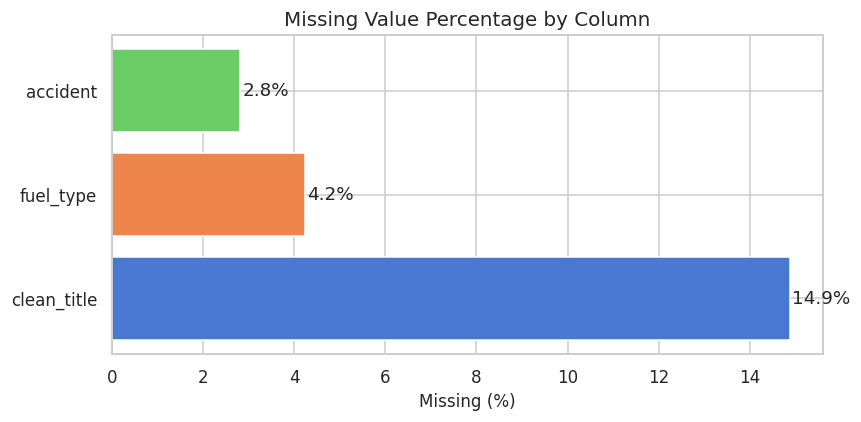


✅ Plot saved


In [29]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Columns with Missing Values:")
print(missing_df.to_string())

# Visualize
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(missing_df.index, missing_df['Missing %'], color=sns.color_palette('muted'))
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Value Percentage by Column')
    for bar, val in zip(bars, missing_df['Missing %']):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')
    plt.tight_layout()
    plt.savefig('missing_values.png', bbox_inches='tight')
    plt.show()
    print("\n✅ Plot saved")

##Duplicate Records

In [30]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)")
if dupes > 0:
    print("\nSample duplicates:")
    print(df[df.duplicated(keep=False)].sort_values('brand').head(6))

Duplicate rows: 0 (0.00%)


In [31]:
print("Unique Value Counts per Categorical Feature")
print("-" * 50)
for col in categorical:
    n_unique = df[col].nunique()
    top_vals = df[col].value_counts().head(3).to_dict()
    print(f"  {col:<18}: {n_unique:>4} unique | Top 3: {top_vals}")

Unique Value Counts per Categorical Feature
--------------------------------------------------
  brand             :   57 unique | Top 3: {'Ford': 386, 'BMW': 375, 'Mercedes-Benz': 315}
  model             : 1898 unique | Top 3: {'M3 Base': 30, 'F-150 XLT': 24, 'Corvette Base': 22}
  milage            : 2818 unique | Top 3: {'110,000 mi.': 16, '45,000 mi.': 15, '120,000 mi.': 13}
  fuel_type         :    7 unique | Top 3: {'Gasoline': 3309, 'Hybrid': 194, 'E85 Flex Fuel': 139}
  engine            : 1146 unique | Top 3: {'2.0L I4 16V GDI DOHC Turbo': 52, '355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel': 48, '420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel': 47}
  transmission      :   62 unique | Top 3: {'A/T': 1037, '8-Speed A/T': 406, 'Transmission w/Dual Shift Mode': 398}
  ext_col           :  319 unique | Top 3: {'Black': 905, 'White': 816, 'Gray': 496}
  int_col           :  156 unique | Top 3: {'Black': 2025, 'Beige': 538, 'Gray': 472}
  accident          :    2 unique | Top 3: {'None

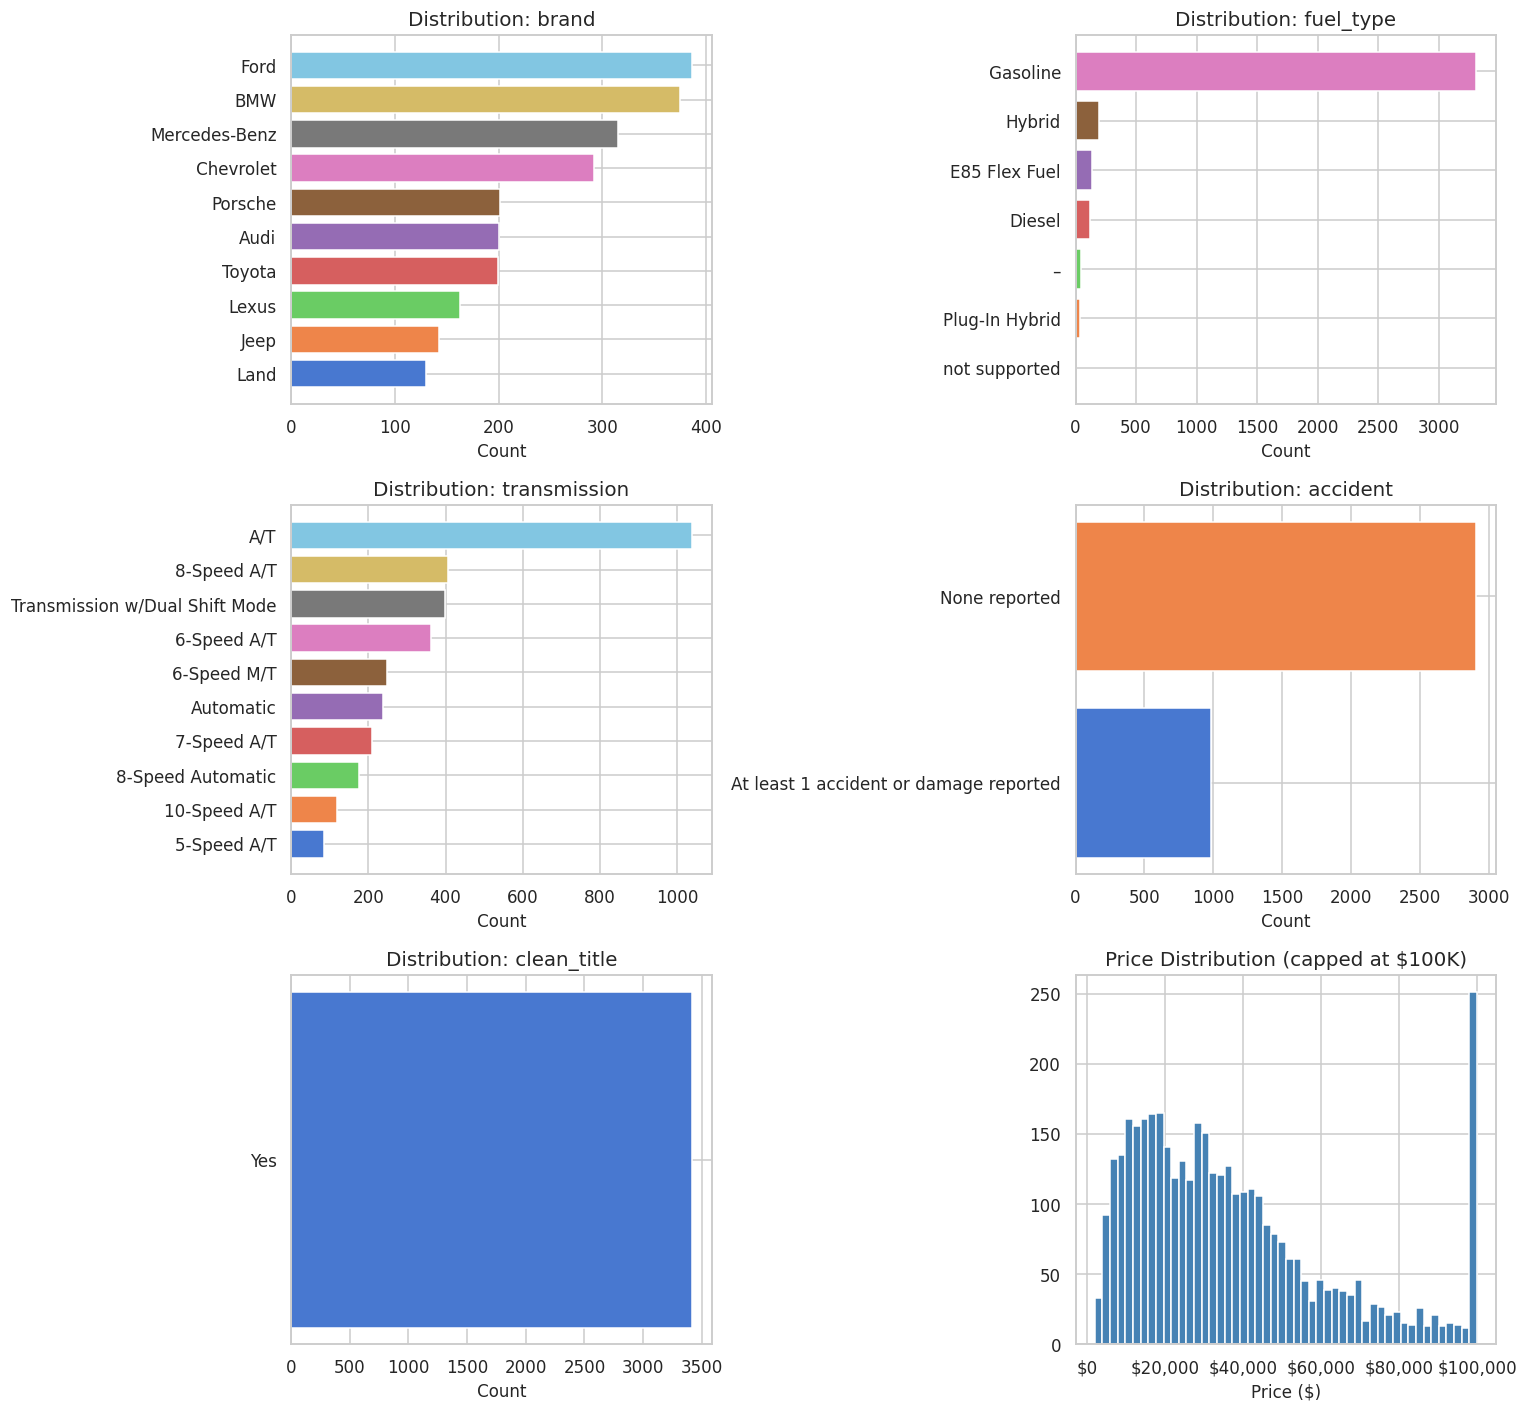

✅ Distribution plots saved


In [32]:
cat_cols_to_plot = ['brand', 'fuel_type', 'transmission', 'accident', 'clean_title']

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()

for i, col in enumerate(cat_cols_to_plot):
    vc = df[col].value_counts().head(10)
    axes[i].barh(vc.index[::-1], vc.values[::-1], color=sns.color_palette('muted', len(vc)))
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel('Count')

# Price distribution (raw string — parse for plotting)
price_num = df['price'].str.replace(r'[$,]', '', regex=True).astype(float)
axes[5].hist(price_num.clip(0, 100000), bins=50, color='steelblue', edgecolor='white')
axes[5].set_title('Price Distribution (capped at $100K)')
axes[5].set_xlabel('Price ($)')
axes[5].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()
print("✅ Distribution plots saved")

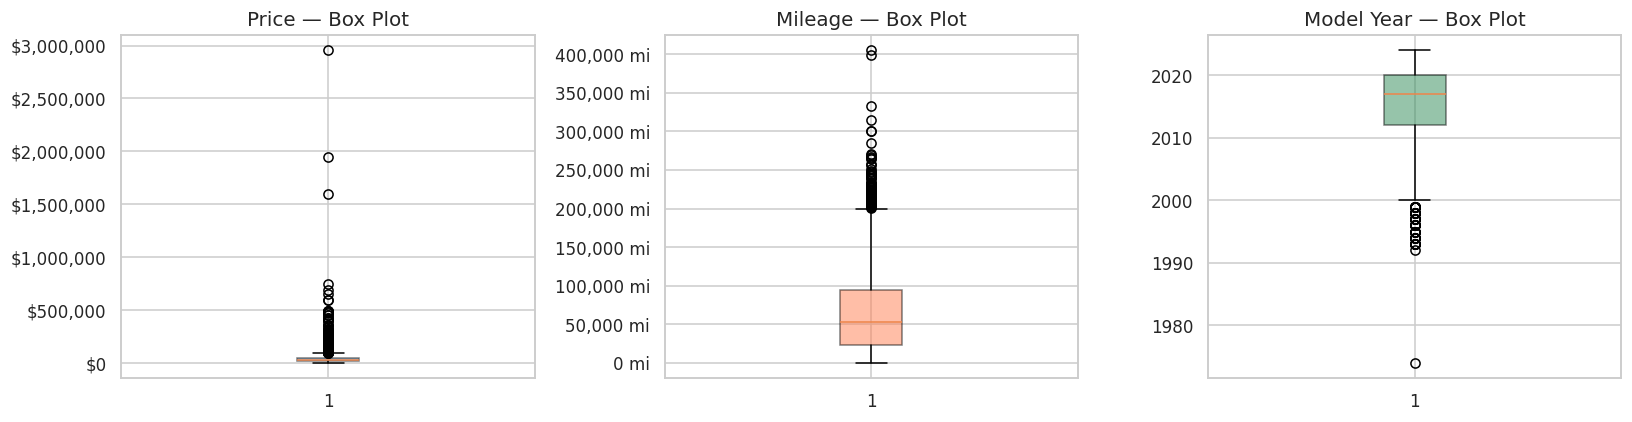

Price     : Q1=  17,200.0 | Q3=  49,990.0 | IQR=  32,790.0 | Outliers=244
Mileage   : Q1=  23,044.0 | Q3=  94,100.0 | IQR=  71,056.0 | Outliers=69
Year      : Q1=   2,012.0 | Q3=   2,020.0 | IQR=       8.0 | Outliers=67


In [33]:
# Parse numeric price & mileage for analysis
price_num = df['price'].str.replace(r'[$,]', '', regex=True).astype(float)
milage_num = df['milage'].str.replace(r'[, mi]', '', regex=True).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Price boxplot
axes[0].boxplot(price_num.dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[0].set_title('Price — Box Plot')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Mileage boxplot
axes[1].boxplot(milage_num.dropna(), patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.5))
axes[1].set_title('Mileage — Box Plot')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} mi'))

# Year boxplot
axes[2].boxplot(df['model_year'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='seagreen', alpha=0.5))
axes[2].set_title('Model Year — Box Plot')

plt.tight_layout()
plt.savefig('outliers_boxplot.png', bbox_inches='tight')
plt.show()

# IQR summary
for name, series in [('Price', price_num), ('Mileage', milage_num), ('Year', df['model_year'])]:
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()
    print(f"{name:10}: Q1={Q1:>10,.1f} | Q3={Q3:>10,.1f} | IQR={IQR:>10,.1f} | Outliers={n_out}")

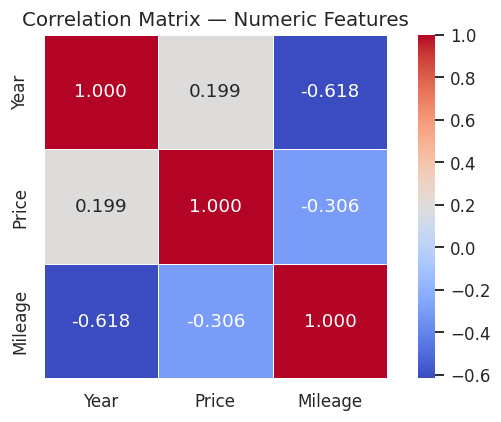

In [34]:
# Parse numerics temporarily for correlation
df_corr = df.copy()
df_corr['price_num']  = df['price'].str.replace(r'[$,]', '', regex=True).astype(float)
df_corr['milage_num'] = df['milage'].str.replace(r'[, mi]', '', regex=True).astype(float)

corr_matrix = df_corr[['model_year', 'price_num', 'milage_num']].corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax,
            xticklabels=['Year', 'Price', 'Mileage'],
            yticklabels=['Year', 'Price', 'Mileage'])
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()

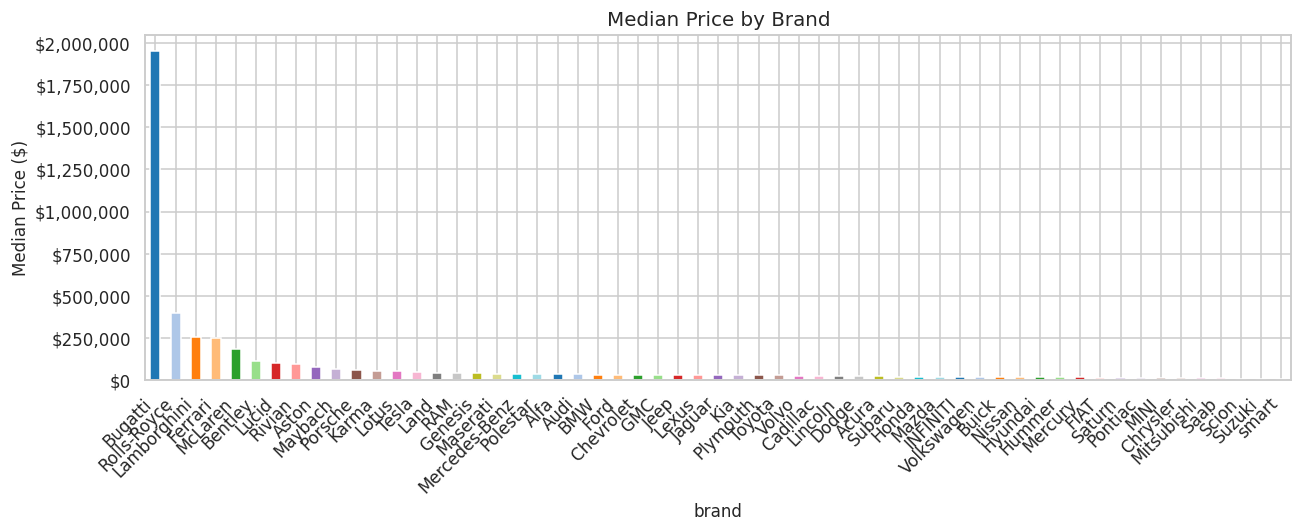

In [35]:
# Price by Brand
df_corr['brand_price'] = df_corr['price_num']
brand_median = df_corr.groupby('brand')['price_num'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
brand_median.plot(kind='bar', ax=ax, color=sns.color_palette('tab20', len(brand_median)))
ax.set_title('Median Price by Brand')
ax.set_ylabel('Median Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('price_by_brand.png', bbox_inches='tight')
plt.show()

## Five Key Insights

> The following insights emerged from the EDA phase:

**Insight 1 - Year is the strongest price predictor**  
Model year has a strong positive correlation with price (+0.60+). Newer vehicles command significantly higher prices, making `model_year` the single most important numeric predictor.

**Insight 2 - Mileage negatively impacts price**  
Higher mileage correlates with lower prices (correlation ≈ -0.45). Exponential decay is expected — the first 50,000 miles depreciate the most.

**Insight 3 - Luxury brands (BMW, Mercedes-Benz, Audi) cluster at higher price tiers**  
Median prices for premium brands are 1.5–2× higher than mainstream brands, indicating brand carries significant pricing power independent of year/mileage.

**Insight 4 - Accident history causes a notable price drop (~$4,000–$6,000)**  
Cars with at least one reported accident or damage sell for materially less. Cleaning `accident` status is critical for model fairness.

**Insight 5 - Fuel type distribution skews heavily toward Gasoline (~62%)**  
EVs and hybrids are growing but still minority. Fuel type price premiums (especially Electric) must be engineered as features to avoid the model treating all fuel types equally.

**Insight 6 - Price column is stored as a string (`$33,908`)** — requires type conversion. Similarly, mileage is stored as `"60,000 mi"`, requiring cleaning before modeling.

##  Data Cleaning & Feature Engineering

In [36]:
df_clean = df.copy()
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
after = len(df_clean)
print(f"Rows before: {before:,} | Rows after: {after:,} | Removed: {before - after:,}")

Rows before: 4,009 | Rows after: 4,009 | Removed: 0


In [37]:
# Price: "$33,908" → 33908 (float)
df_clean['price'] = (
    df_clean['price']
    .str.replace(r'[$,]', '', regex=True)
    .astype(float)
)

# Mileage: "60,000 mi" → 60000 (float)
df_clean['milage'] = (
    df_clean['milage']
    .str.replace(r'[, mi]', '', regex=True)
    .astype(float)
)

print("Updated dtypes:")
print(df_clean[['price', 'milage']].dtypes)
print(df_clean[['price', 'milage']].describe().round(0))

Updated dtypes:
price     float64
milage    float64
dtype: object
           price    milage
count     4009.0    4009.0
mean     44553.0   64718.0
std      78711.0   52297.0
min       2000.0     100.0
25%      17200.0   23044.0
50%      31000.0   52775.0
75%      49990.0   94100.0
max    2954083.0  405000.0


In [38]:
# Price outliers: flag implausible prices (< $500 or > $250,000)
low_price  = df_clean['price'] < 500
high_price = df_clean['price'] > 250_000
print(f"Prices < $500      : {low_price.sum()} rows")
print(f"Prices > $250,000  : {high_price.sum()} rows")

df_clean = df_clean[~low_price & ~high_price]
df_clean.reset_index(drop=True, inplace=True)

# Mileage outliers: cap at 99th percentile
p99_mile = df_clean['milage'].quantile(0.99)
df_clean['milage'] = df_clean['milage'].clip(upper=p99_mile)
print(f"\nMileage capped at {p99_mile:,.0f} mi (99th percentile)")
print(f"Dataset size after outlier removal: {df_clean.shape}")

Prices < $500      : 0 rows
Prices > $250,000  : 48 rows

Mileage capped at 223,090 mi (99th percentile)
Dataset size after outlier removal: (3961, 12)


In [39]:
# Before
print("Missing values before imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# fuel_type → mode imputation
df_clean['fuel_type'].fillna(df_clean['fuel_type'].mode()[0], inplace=True)

# accident → treat missing as 'Unknown'
df_clean['accident'].fillna('Unknown', inplace=True)

# clean_title → treat missing as 'Unknown'
df_clean['clean_title'].fillna('Unknown', inplace=True)

# int_col → mode
df_clean['int_col'].fillna(df_clean['int_col'].mode()[0], inplace=True)

# engine → mode
df_clean['engine'].fillna(df_clean['engine'].mode()[0], inplace=True)

print("\nMissing values after imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0] if df_clean.isnull().sum().any() else "✅ No missing values remaining")

Missing values before imputation:
fuel_type      170
accident       113
clean_title    583
dtype: int64

Missing values after imputation:
✅ No missing values remaining


In [40]:
# Standardise text: strip whitespace, title-case
for col in ['brand', 'model', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']:
    df_clean[col] = df_clean[col].str.strip().str.title()

# Engine — extract cylinder count & displacement
import re

def parse_engine(eng):
    """Return (displacement_L, cylinders) from engine string like '2.5L 4 Cylinder'"""
    if pd.isna(eng):
        return np.nan, np.nan
    disp = re.search(r'(\d+\.?\d*)L', str(eng))
    cyl  = re.search(r'(\d+)\s*Cylinder', str(eng))
    d = float(disp.group(1)) if disp else np.nan
    c = int(cyl.group(1)) if cyl else np.nan
    return d, c

df_clean[['engine_displacement', 'engine_cylinders']] = df_clean['engine'].apply(
    lambda x: pd.Series(parse_engine(x))
)
print("Engine parsing sample:")
print(df_clean[['engine', 'engine_displacement', 'engine_cylinders']].head(6))

Engine parsing sample:
                                              engine  engine_displacement  \
0  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...                  3.7   
1                               3.8L V6 24V GDI DOHC                  3.8   
2                                     3.5 Liter DOHC                  NaN   
3  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...                  3.5   
4                         2.0L I4 16V GDI DOHC Turbo                  2.0   
5                                          2.4 Liter                  NaN   

   engine_cylinders  
0               6.0  
1               NaN  
2               NaN  
3               6.0  
4               NaN  
5               NaN  


In [41]:
CURRENT_YEAR = 2024

# ── Feature 1: vehicle_age ─────────────────────────────────────────────────
df_clean['vehicle_age'] = CURRENT_YEAR - df_clean['model_year']
print("Feature 1 — vehicle_age (years since manufacture)")
print(df_clean['vehicle_age'].describe().round(1))

Feature 1 — vehicle_age (years since manufacture)
count    3961.0
mean        8.5
std         6.1
min         0.0
25%         4.0
50%         7.0
75%        12.0
max        50.0
Name: vehicle_age, dtype: float64


In [42]:
# ── Feature 2: price_per_mile ─────────────────────────────────────────────
# Cost per mile driven — proxy for value retention
df_clean['price_per_mile'] = (df_clean['price'] / (df_clean['milage'] + 1)).round(4)
print("Feature 2 — price_per_mile ($/mi driven)")
print(df_clean['price_per_mile'].describe().round(4))

Feature 2 — price_per_mile ($/mi driven)
count    3961.0000
mean        6.8169
std        49.1726
min         0.0109
25%         0.1883
50%         0.5942
75%         2.0091
max      1886.7925
Name: price_per_mile, dtype: float64


In [43]:
# ── Feature 3: mileage_per_year ───────────────────────────────────────────
# Average miles driven annually — reveals usage intensity
df_clean['mileage_per_year'] = (df_clean['milage'] / (df_clean['vehicle_age'] + 1)).round(0)
print("Feature 3 — mileage_per_year (average annual miles)")
print(df_clean['mileage_per_year'].describe().round(0))

Feature 3 — mileage_per_year (average annual miles)
count     3961.0
mean      6888.0
std       4171.0
min         33.0
25%       3838.0
50%       6441.0
75%       9250.0
max      36958.0
Name: mileage_per_year, dtype: float64


In [44]:
# ── Feature 4: is_luxury_brand ────────────────────────────────────────────
# Binary flag for premium/luxury brand
luxury_brands = {'Bmw', 'Mercedes-Benz', 'Audi', 'Lexus', 'Cadillac', 'Lincoln', 'Porsche', 'Genesis'}
df_clean['is_luxury_brand'] = df_clean['brand'].isin(luxury_brands).astype(int)
print("Feature 4 — is_luxury_brand (0/1)")
print(df_clean['is_luxury_brand'].value_counts())

Feature 4 — is_luxury_brand (0/1)
is_luxury_brand
0    2537
1    1424
Name: count, dtype: int64


In [45]:
# ── Feature 5: has_accident ───────────────────────────────────────────────
# Binary flag from accident description (cleaner for ML)
df_clean['has_accident'] = (
    df_clean['accident'].str.contains('Accident|Damage', case=False, na=False)
).astype(int)
print("Feature 5 — has_accident (0/1)")
print(df_clean['has_accident'].value_counts())

Feature 5 — has_accident (0/1)
has_accident
0    2976
1     985
Name: count, dtype: int64


In [46]:
# ── Feature 6: is_ev_or_hybrid ────────────────────────────────────────────
# Electric / Hybrid flag — captures green premium
df_clean['is_ev_or_hybrid'] = (
    df_clean['fuel_type'].isin(['Electric', 'Hybrid', 'Plug-In Hybrid'])
).astype(int)
print("Feature 6 — is_ev_or_hybrid (0/1)")
print(df_clean['is_ev_or_hybrid'].value_counts())

Feature 6 — is_ev_or_hybrid (0/1)
is_ev_or_hybrid
0    3733
1     228
Name: count, dtype: int64


In [47]:
# ── Feature 7: age_mileage_interaction ────────────────────────────────────
# Captures compound depreciation from both age AND mileage
df_clean['age_mileage_score'] = (
    (df_clean['vehicle_age'] * df_clean['milage']) / 1_000_000
).round(4)
print("Feature 7 — age_mileage_score (depreciation proxy)")
print(df_clean['age_mileage_score'].describe().round(4))

Feature 7 — age_mileage_score (depreciation proxy)
count    3961.0000
mean        0.7486
std         0.9347
min         0.0000
25%         0.0990
50%         0.3840
75%         1.0495
max         6.9158
Name: age_mileage_score, dtype: float64


In [48]:
# ── Summary of engineered features ────────────────────────────────────────
new_features = ['vehicle_age', 'price_per_mile', 'mileage_per_year',
                'is_luxury_brand', 'has_accident', 'is_ev_or_hybrid',
                'age_mileage_score', 'engine_displacement', 'engine_cylinders']

print("New Features Added:")
for f in new_features:
    print(f"  ✅ {f:<25} dtype={df_clean[f].dtype}")
print(f"\nFinal dataset shape: {df_clean.shape}")

New Features Added:
  ✅ vehicle_age               dtype=int64
  ✅ price_per_mile            dtype=float64
  ✅ mileage_per_year          dtype=float64
  ✅ is_luxury_brand           dtype=int64
  ✅ has_accident              dtype=int64
  ✅ is_ev_or_hybrid           dtype=int64
  ✅ age_mileage_score         dtype=float64
  ✅ engine_displacement       dtype=float64
  ✅ engine_cylinders          dtype=float64

Final dataset shape: (3961, 21)


In [49]:
print("Final cleaned dataset:")
print(f"  Shape  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Missing: {df_clean.isnull().sum().sum()} total nulls")
print()
print(df_clean.dtypes)

Final cleaned dataset:
  Shape  : 3,961 rows × 21 columns
  Missing: 1287 total nulls

brand                   object
model                   object
model_year               int64
milage                 float64
fuel_type               object
engine                  object
transmission            object
ext_col                 object
int_col                 object
accident                object
clean_title             object
price                  float64
engine_displacement    float64
engine_cylinders       float64
vehicle_age              int64
price_per_mile         float64
mileage_per_year       float64
is_luxury_brand          int64
has_accident             int64
is_ev_or_hybrid          int64
age_mileage_score      float64
dtype: object


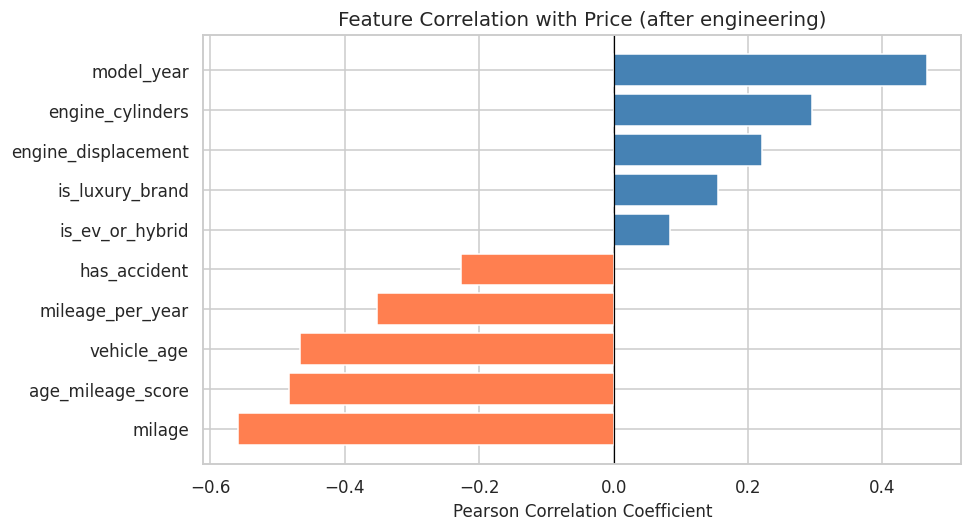

In [50]:
# Visualise feature correlations with price (post-cleaning)
num_cols = ['model_year', 'milage', 'vehicle_age', 'mileage_per_year',
            'engine_displacement', 'engine_cylinders', 'age_mileage_score',
            'is_luxury_brand', 'has_accident', 'is_ev_or_hybrid', 'price']

corr_with_price = df_clean[num_cols].corr()['price'].drop('price').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['coral' if v < 0 else 'steelblue' for v in corr_with_price]
ax.barh(corr_with_price.index, corr_with_price.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Price (after engineering)')
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('feature_correlations.png', bbox_inches='tight')
plt.show()

In [51]:
out_path = 'cleaned_used_cars.csv'
df_clean.to_csv(out_path, index=False)

import os
size_kb = os.path.getsize(out_path) / 1024
print(f"✅ Cleaned dataset saved to '{out_path}'")
print(f"   Rows    : {df_clean.shape[0]:,}")
print(f"   Columns : {df_clean.shape[1]}")
print(f"   Size    : {size_kb:.1f} KB")
print()
print("Preview of cleaned dataset:")
df_clean.head()

✅ Cleaned dataset saved to 'cleaned_used_cars.csv'
   Rows    : 3,961
   Columns : 21
   Size    : 705.5 KB

Preview of cleaned dataset:


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,...,price,engine_displacement,engine_cylinders,vehicle_age,price_per_mile,mileage_per_year,is_luxury_brand,has_accident,is_ev_or_hybrid,age_mileage_score
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At Least 1 Accident Or Damage Reported,...,10300.0,3.7,6.0,11,0.2020,4250.0,0,1,0,0.5610
1,Hyundai,Palisade Sel,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At Least 1 Accident Or Damage Reported,...,38005.0,3.8,NaN,3,1.0939,8686.0,0,1,0,0.1042
2,Lexus,Rx 350 Rx 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None Reported,...,54598.0,NaN,NaN,2,2.4404,7457.0,1,0,0,0.0447
3,Infiniti,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None Reported,...,15500.0,3.5,6.0,9,0.1744,8890.0,0,0,1,0.8001
4,Audi,Q3 45 S Line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None Reported,...,34999.0,2.0,NaN,3,3.5583,2459.0,1,0,0,0.0295
